In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)
# tf.config.run_functions_eagerly(True)

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from tqdm import tqdm
from icecream import ic

from msfm.grid_pipeline import GridPipeline
from msfm.utils import logger, files, scales, power_spectra, parameters

from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import optimization, configuration
from deep_lss.nets.mlp import MultiLayerPerceptron

from msi.utils import preprocessing, dataset, input_output

### v10

In [3]:
# msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v10/linear_bias"
# mocks = ["Buzzard", "Cardinal"]
# # # mocks = ["Buzzard", "Buzzard_mocked_DNF", "Cardinal"]

# # msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias_octant.yaml")
# # base_dir = "/pscratch/sd/a/athomsen/v11desy3/v10/linear_bias_octant"
# # mocks = ["MICE", "Euclid"]

# # for the white noise level
# dlss_conf = configuration.load_deep_lss_config("/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/dlss_config.yaml")
# # dlss_conf = configuration.load_deep_lss_config("/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/dlss_high_noise.yaml")

# # dlss_conf = configuration.load_deep_lss_config("/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/noise_levels/dlss_1%.yaml")
# # dlss_conf = configuration.load_deep_lss_config("/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/noise_levels/dlss_10%.yaml")
# # dlss_conf = configuration.load_deep_lss_config("/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/noise_levels/dlss_naive.yaml")

# # dlss_conf = configuration.load_deep_lss_config(
# #     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_28mpc.yaml"
# # )


# # label = "16mpc"
# # label = "20mpc"
# # label = "24mpc"
# # label = "28mpc"
# # dlss_conf = configuration.load_deep_lss_config(
# #     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_{label}.yaml"
# # )
# # label += "_octant"
# # label += "_flock"

# out_dir = "/pscratch/sd/a/athomsen/run_files/v10"
# # out_dir = "/pscratch/sd/a/athomsen/run_files/v10/octant"
# # label = "default,new"
# # label = "default,from_maps"
# # label = "default,1%noise"
# # label = "default,10%noise"
# # label = "default,naive_noise"

# # label = "no_ell_in_bins_[:8]"
# # label = "no_ell_in_bins_[:2]"
# # label = "no_ell_in_bins_[-8:]"
# # label = "high_noise"
# # label = "no_noise"
# # label = "legacy,fixed_binning"
# # label = "legacy,l_min=0"
# # label = "legacy,corrected,l_min"
# # label = "euclid"

# # label = "z_consistency,auto"
# # [26, 30, 33, 35]
# # bin_index = 35
# # label = f"z_consistency,{bin_index}"

# # l_max = [267, 390, 510, 610]
# # label = "hard_cut"

# # label = "smoothing_big,noise_small"
# # theta_fwhm = [22.1, 15.1, 11.2, 9.4, 65.1, 44.5, 34.1, 28.5]
# # white_noise_sigma = [2.3090e-04, 3.0336e-04, 4.1867e-04, 1.0056e-03, 5.0699e-01, 2.1057e-01, 1.5098e-01, 1.3614e-01]

# label = "smoothing_small,noise_big"
# theta_fwhm = 0.707 * np.array([22.1, 15.1, 11.2, 9.4, 65.1, 44.5, 34.1, 28.5])
# white_noise_sigma = [7.3134e-04, 9.7611e-04, 1.2943e-03, 2.2269e-03, 1.6128e+00, 6.6656e-01, 4.6794e-01, 4.3220e-01]

In [4]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]
# mocks = []

In [5]:
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "bg", "n_bg"]

In [6]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# mocks = []

### v11

In [7]:
# msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v11/extended.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v11/extended"
# mocks = ["Buzzard", "Cardinal"]

# # dlss_conf = configuration.load_deep_lss_config(
# #     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_28mpc.yaml"
# # )


# label = "16mpc"
# # label = "20mpc"
# # label = "24mpc"
# # label = "28mpc"
# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_{label}.yaml"
# )
# # label += "_octant"

# out_dir = "/pscratch/sd/a/athomsen/run_files/v11"
# # out_dir += "/octant"

In [8]:
# with_lensing = True
# with_clustering = False
# with_cross_z = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# mocks = []

In [9]:
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

In [10]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# mocks = []

### v12

In [11]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v12/nonlinear.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v12/nonlinear"
mocks = ["Buzzard", "Cardinal"]

# dlss_conf = configuration.load_deep_lss_config(
#     f"/global/u2/a/athomsen/y3-deep-lss/configs/v10/clustering/smoothing_fwhm/dlss_28mpc.yaml"
# )

# label = "16mpc"
label = "20mpc"
# label = "24mpc"
# label = "28mpc"
dlss_conf = configuration.load_deep_lss_config(
    f"/global/u2/a/athomsen/y3-deep-lss/configs/v12/clustering/smoothing_fwhm/dlss_{label}.yaml"
)
# label += "_octant"
# label += "_no_cross_z"

out_dir = "/pscratch/sd/a/athomsen/run_files/v12"
# out_dir += "/octant"

24-10-25 09:32:07 configuratio INF   Loaded the config 


In [12]:
# with_lensing = True
# with_clustering = False
# with_cross_z = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# mocks = []

In [13]:
with_lensing = False
with_clustering = True
with_cross_z = True
params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4", "qbg1", "qbg2", "qbg3", "qbg4"]

In [14]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# mocks = []

# constants

In [15]:
batch_size = 2**12
# batch_size = 2**10
shuffle_buffer = 4*batch_size
apply_log = True
standardize = False

cosine_decay = False
n_steps = 100_000
# n_steps = 200_000

out_dir = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},standard={standardize},log={apply_log},cosine={cosine_decay},steps={n_steps}")
if label is not None:
    out_dir = os.path.join(out_dir, label)
os.makedirs(out_dir, exist_ok=True)

# white noise dset

24-10-25 09:32:09 configuratio INF   Loaded the config 
24-10-25 09:32:09 preprocessin INF   Using theta_fwhm = [22.1, 15.1, 11.2, 9.4, 81.4, 55.6, 42.6, 35.7] from the dlss config 
24-10-25 09:32:09 preprocessin INF   Using white_noise_sigma = [0.0010012, 0.0013444, 0.0016358, 0.0017096, 0.61874, 0.24366, 0.17824, 0.16407] from the dlss config 
24-10-25 09:32:09 preprocessin INF   Using l_maxs = [ 488.68778281  715.23178808  964.28571429 1148.93617021  132.67813268
  194.24460432  253.52112676  302.5210084 ] from the dlss config 
24-10-25 09:32:09 preprocessin INF   Using l_mins = [0. 0. 0. 0. 0. 0. 0. 0.] by default (no smoothing) 
24-10-25 09:32:09 preprocessin INF   Using n_bins = 33 from the msfm config 
24-10-25 09:32:09 preprocessin INF   Loading the pre-binned Cls 
24-10-25 09:32:09 input_output INF   Loading summaries from /pscratch/sd/a/athomsen/v11desy3/v12/nonlinear 
24-10-25 09:32:09 input_output INF   Array shapes: 
24-10-25 09:32:09 input_output INF   fiducial/i_example 

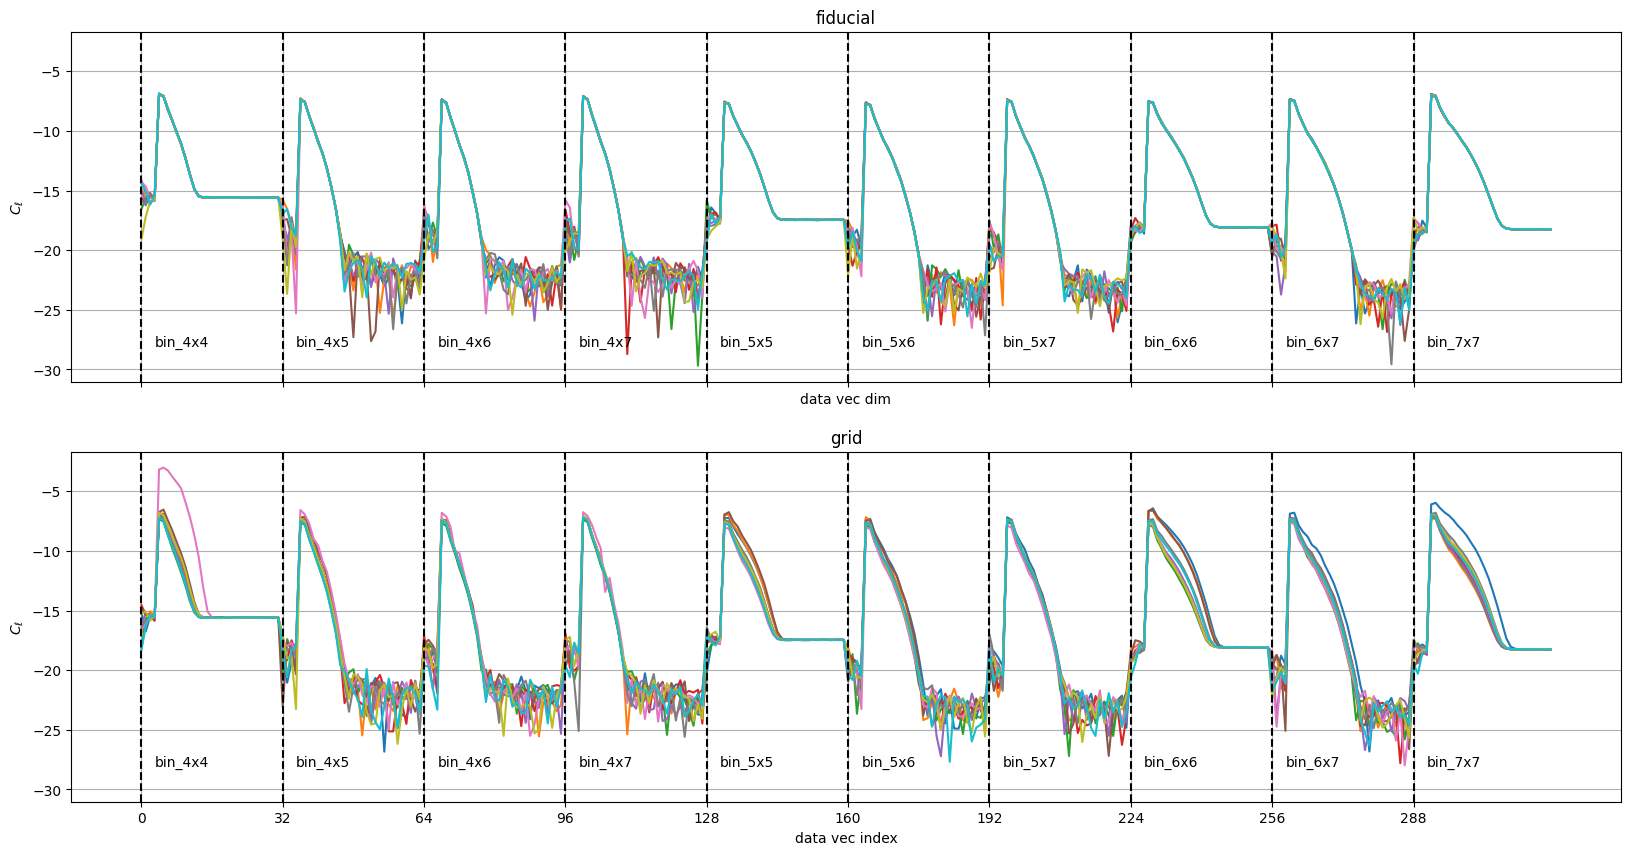

In [16]:
cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_gaussian_noise=True,
    # bin_indices=[bin_index],
    # dset
    batch_size=batch_size,
    shuffle_buffer=shuffle_buffer,
    # smoothing not from the dlss_conf
    # theta_fwhms=theta_fwhm,
    # white_noise_sigmas=white_noise_sigma,
    # cls_from_maps=True,
    # preprocessing
    apply_log=apply_log,
    standardize=standardize,
)

# hard cut dset

In [17]:
# l_mins = 8 * [30]
# l_maxs = [786, 1150, 1535, 1535, 267, 390, 509, 610]

# # def angle_to_ell(angles):
# #     return list(scales.angle_to_ell(np.array(angles), arcmin=True))
# # l_maxs = angle_to_ell([22.1, 15.1, 11.2, 9.4] + [65.1, 44.5, 34.1, 28.5])

# cl_dset_train, cl_dset_test, out_dict, scaler, pca = dataset.get_binned_power_spectra_dset_legacy(
#     base_dir, 
#     # configuration
#     msfm_conf=msfm_conf, 
#     dlss_conf=dlss_conf,
#     params=params,
#     # selection
#     with_lensing=with_lensing,
#     with_clustering=with_clustering,
#     # dset
#     batch_size=batch_size,
#     shuffle_buffer=shuffle_buffer,
#     # power spectra
#     l_mins=l_mins,
#     l_maxs=l_maxs,
#     # n_bins=n_bins,
#     fixed_binning=False,
#     # additional preprocessing
#     apply_log=apply_log,
#     standardize=standardize,
# )

In [18]:
# fig, ax = plt.subplots()

# steps = 3
# for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(steps)), total=steps):
#     ax.plot(cl_batch[0])

# ax.set(xlabel=r"$\ell$", ylabel=r"$C_\ell$")

# functions and global constants

In [19]:
n_cls = out_dict["grid/cls/train"].shape[-1]
n_params = len(params)
n_summary = n_params

num_hidden_units = 1024
num_layers = 2

# num_hidden_units = 256
# num_layers = 4

dropout_rate = 0.1

def get_cl_summary_network(n_summary=n_summary):
    mlp = MultiLayerPerceptron(
        output_size=n_summary, 
        num_hidden_units=num_hidden_units, 
        num_layers=num_layers, 
        dropout_rate=dropout_rate
    )
    mlp.build((None, n_cls))
    
    return mlp

In [20]:
def train_model(model, eval_every=None):
    do_validation = eval_every is not None
    
    train_losses = []
    train_steps = []
    vali_steps = []
    vali_losses = []
    for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(n_steps+1)), total=n_steps):
        train_losses.append(model.grid_train_step(cl_batch, cosmo_batch))
        train_steps.append(i)
        
        if do_validation and (i % eval_every == 0) and (i !=0):
            vali_loss = []
            for cl_batch, cosmo_batch in cl_dset_test:
                vali_loss.append(model.vali_loss_fn(model(cl_batch, training=False), cosmo_batch))
            vali_losses.append(np.mean(vali_loss))
            vali_steps.append(i)

    fig, ax = plt.subplots()
    ax.plot(train_steps[100:], train_losses[100:], label="training")
    ax.plot(vali_steps, vali_losses, label="validation")
    ax.legend()
    
    if do_validation:
        print(f"final validation loss = {vali_losses[-1]}")
        
    model.save_model()

# variational lower bound

24-10-25 09:33:15 base_model.p INF   Initializing with a normal Sequential model 
24-10-25 09:33:15 base_model.p INF   The network is initialized from scratch. 
24-10-25 09:33:15 grid_model.p INF   Initialized the GridLossModel 
24-10-25 09:33:15 grid_model.p WAR   Mutual info loss, overwriting the checkpoint manager 
24-10-25 09:33:15 grid_model.p WAR   Using the mutual information loss with the variational estimator 
24-10-25 09:33:15 grid_model.p INF   Set up the training step of the mutual_info loss 


  0%|          | 0/100000 [00:00<?, ?it/s]

24-10-25 09:33:18 grid_model.p WAR   Tracing grid_train_step 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
24-10-25 09:33:20 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
24-10-25 09:33:21 grid_model.p WAR   Tracing grid_train_step 
24-10-25 09:33:21 base_model.p W

100001it [35:41, 46.70it/s]                             


final validation loss = -1.2604999542236328
24-10-25 10:09:02 base_model.p INF   Successfully saved the model in /pscratch/sd/a/athomsen/run_files/v12/cls/mutual_info/lensing=False,clustering=True,standard=False,log=True,cosine=False,steps=100000/20mpc/model 


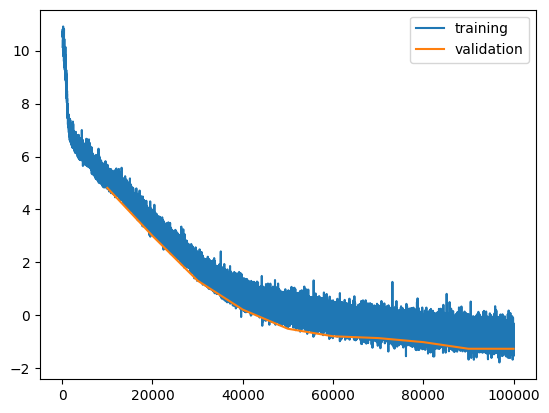

In [21]:
learning_rate = 1e-4

summary_net = get_cl_summary_network()

if cosine_decay:
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=learning_rate, decay_steps=n_steps, alpha=0.0
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
else:
    optimizer = tf.keras.optimizers.Adam(learning_rate)
    
model = GridLossModel(
    summary_net,
    n_side=None,
    indices=None,
    optimizer=optimizer,
    checkpoint_dir=os.path.join(out_dir, "model"),
    # restore_checkpoint=True,
)

model.setup_grid_loss_step(
    batch_size=batch_size,
    dim_theta=n_params,
    loss="mutual_info",
    dim_x=n_cls,
    dim_summary=n_summary,
    mutual_info_estimator="variational",
    clip_by_global_norm=1.0,
    mutual_info_kwargs={"full_covariance": False},
)

train_model(model, eval_every=n_steps//10)

In [22]:
# train_model(model, eval_every=n_steps//10)
# n_steps = 200_000

# save the results

In [23]:
fidu_preds = model(out_dict["fidu/cls"])
grid_preds = model(out_dict["grid/cls/test"])

pred_file = os.path.join(out_dir, "preds.h5")
with h5py.File(pred_file, "w") as f:
    f.create_dataset(name="grid/preds/test", data=grid_preds)
    f.create_dataset(name="grid/cosmos/test", data=out_dict["grid/cosmos/test"])
    f.create_dataset(name="fidu/preds", data=fidu_preds)

print(f"Wrote to {pred_file}\n")
print(fidu_preds)

Wrote to /pscratch/sd/a/athomsen/run_files/v12/cls/mutual_info/lensing=False,clustering=True,standard=False,log=True,cosine=False,steps=100000/20mpc/preds.h5

tf.Tensor(
[[ 0.45567518 -0.0278386   0.1705068  ...  1.1038978  -0.582657
   0.46307552]
 [ 0.38455084 -0.06849575  0.11699745 ...  1.1317971  -0.55273354
   0.3951383 ]
 [ 0.4276418   0.04570591  0.12824517 ...  1.0101002  -0.6753086
   0.3240297 ]
 ...
 [ 0.2036057   0.23565428  0.5216649  ...  0.9761926  -0.6731239
   0.25198817]
 [ 0.2532376   0.25828966  0.5049539  ...  0.95051503 -0.74166596
   0.31415492]
 [ 0.15793024  0.30002502  0.71350956 ...  0.93830085 -0.6284657
   0.28195155]], shape=(4000, 11), dtype=float32)


### external mocks

24-10-25 10:09:07     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
24-10-25 10:09:07 configuratio INF   Loaded the config 
24-10-25 10:09:07 preprocessin INF   Using l_maxs = [ 488.68778281  715.23178808  964.28571429 1148.93617021  132.67813268
  194.24460432  253.52112676  302.5210084 ] from the dlss config 
24-10-25 10:09:07 preprocessin INF   Using l_mins = [0 0 0 0 0 0 0 0] by default (no smoothing) 
24-10-25 10:09:08     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
24-10-25 10:09:08     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
24-10-25 10:09:32 preprocessin INF   Adding white noise to the observation 
24-10-25 10:09:32 preprocessin INF   Using the bin indices [26, 27, 28, 29, 30, 31, 32, 33, 34, 35] 
24-10-25 10:0

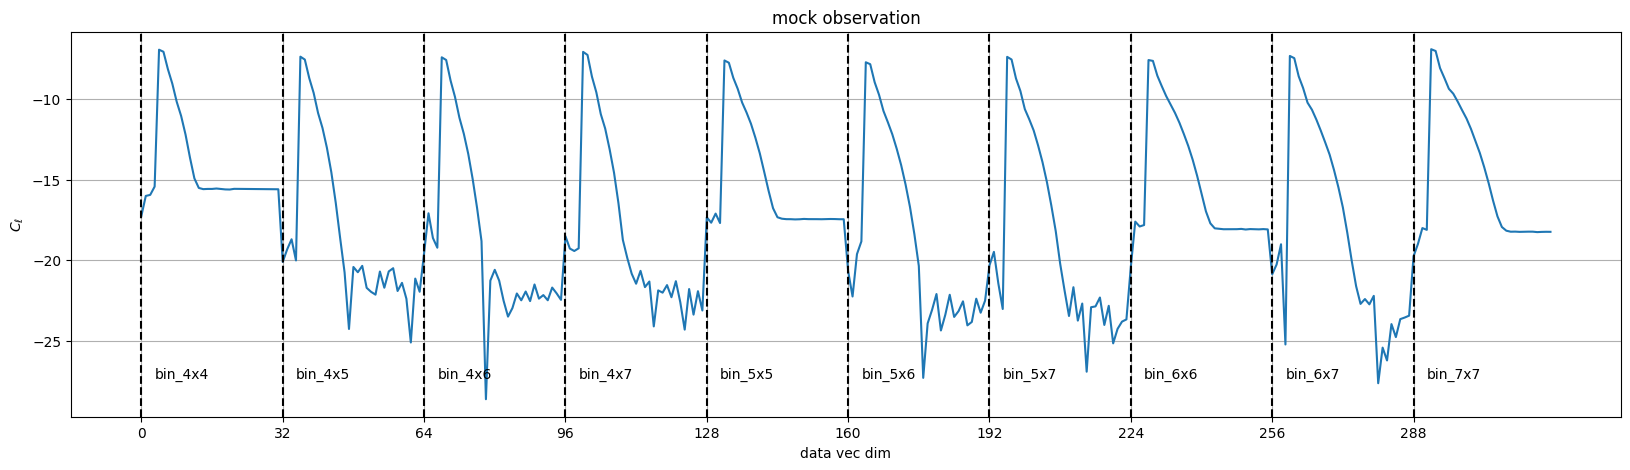

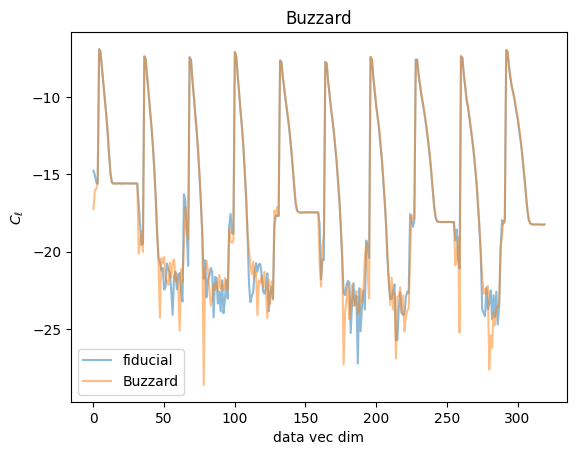

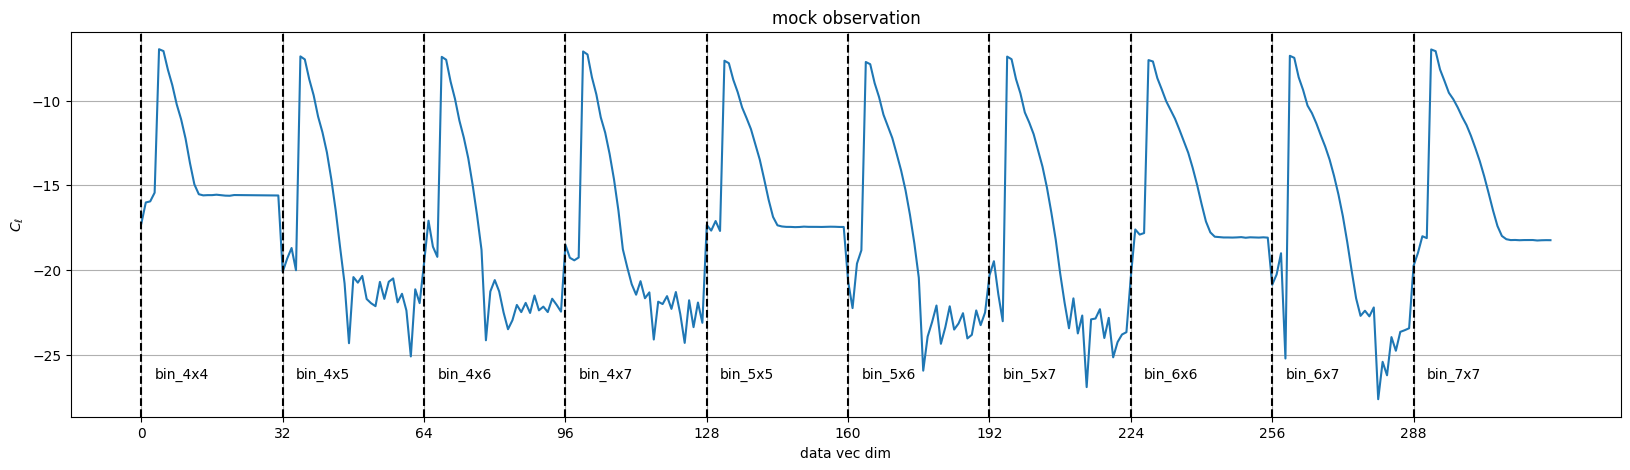

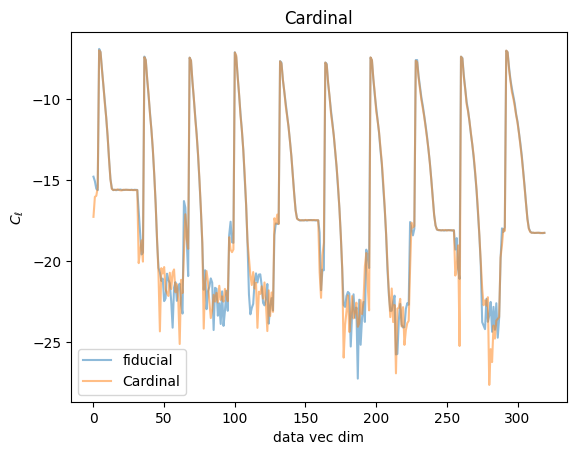

In [24]:
n_side = msfm_conf["analysis"]["n_side"]
n_pix = msfm_conf["analysis"]["n_pix"]
data_vec_pix = files.load_pixel_file(msfm_conf)[0]
hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

with h5py.File(pred_file, "a") as f_out:
    for obs_label in mocks:
        obs_file = f"/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_mock_observation_{obs_label}.h5"

        with h5py.File(obs_file, "r") as f_in:
            gc_map = []
            for i in range(1,5):
                gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
            gc_map = np.stack(gc_map, axis=-1)

        obs_cl = preprocessing.get_preprocessed_cl_observation(
            wl_gamma_map=np.zeros((n_pix,4,2)),
            gc_count_map=gc_map,
            # configuration
            msfm_conf=msfm_conf,
            dlss_conf=dlss_conf,
            base_dir=base_dir,
            from_raw_cls=False,
            # selection
            with_lensing=with_lensing,
            with_clustering=with_clustering,
            with_cross_z=with_cross_z,
            with_cross_probe=(with_lensing and with_clustering),
            # bin_indices=[bin_index],
            # additional preprocessing
            apply_log=apply_log,
            # standardize=standardize,
            # scaler=scaler,
            # pca_components=None,
            # pca=pca,
        )
        
        fig, ax = plt.subplots()
        ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
        ax.plot(np.squeeze(obs_cl), label=obs_label, alpha=0.5)
        ax.legend(loc="best")
        ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$", title=obs_label)

        obs_pred = model(obs_cl)
        print("\n", obs_label, obs_pred, "\n")
            
        f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)


### Buzzard flock

24-10-25 10:10:01     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
24-10-25 10:10:01 configuratio INF   Loaded the config 
24-10-25 10:10:01 preprocessin INF   Using l_maxs = [ 488.68778281  715.23178808  964.28571429 1148.93617021  132.67813268
  194.24460432  253.52112676  302.5210084 ] from the dlss config 
24-10-25 10:10:01 preprocessin INF   Using l_mins = [0 0 0 0 0 0 0 0] by default (no smoothing) 
24-10-25 10:10:01     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
24-10-25 10:10:01     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_fiducial_512.h5 
24-10-25 10:10:20 preprocessin INF   Adding white noise to the observation 
24-10-25 10:10:20 preprocessin INF   Using the bin indices [26, 27, 28, 29, 30, 31, 32, 33, 34, 35] 
24-10-25 10:1

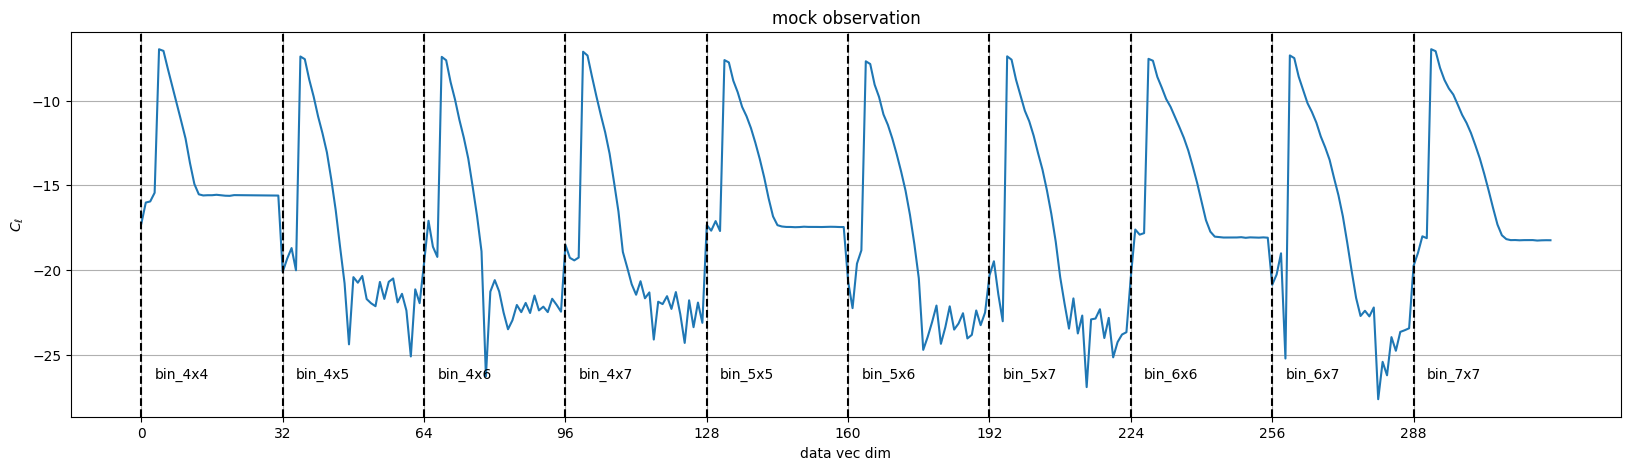

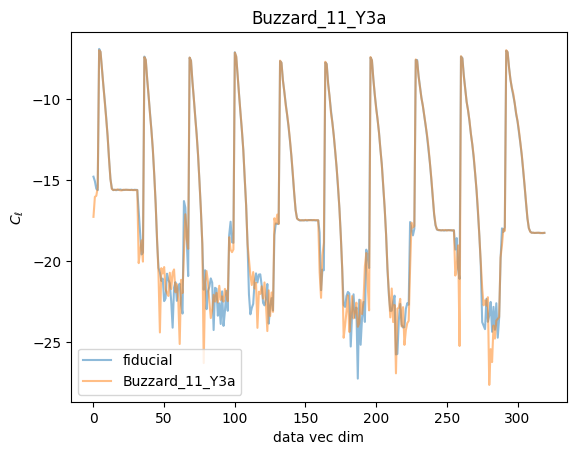

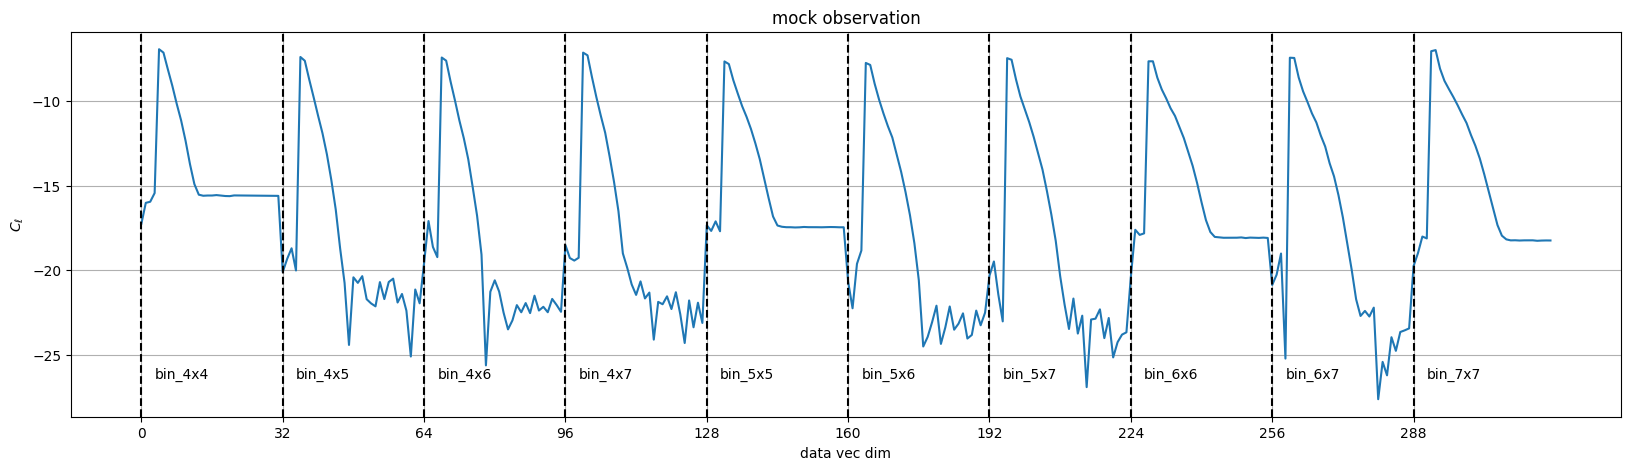

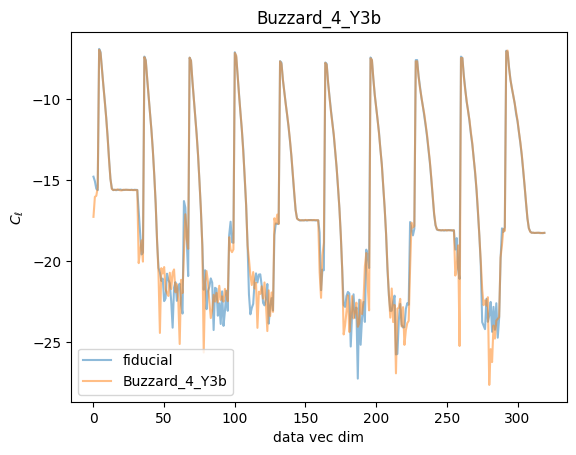

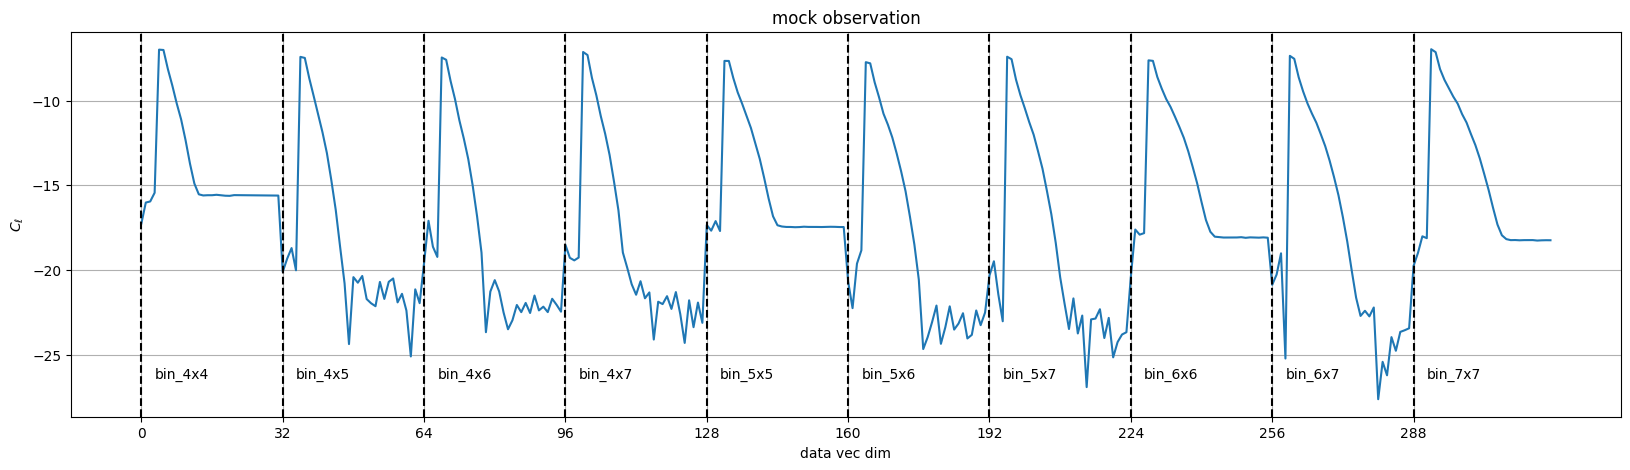

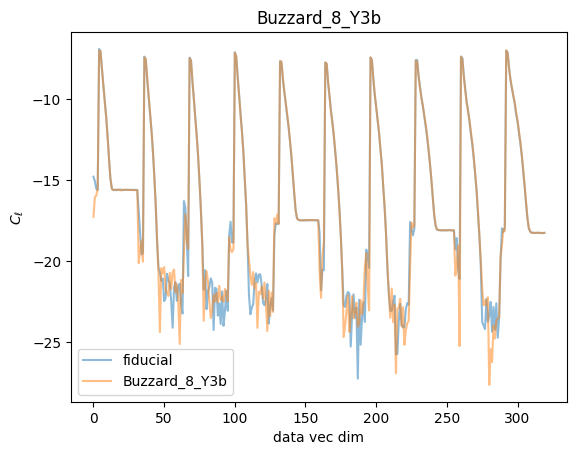

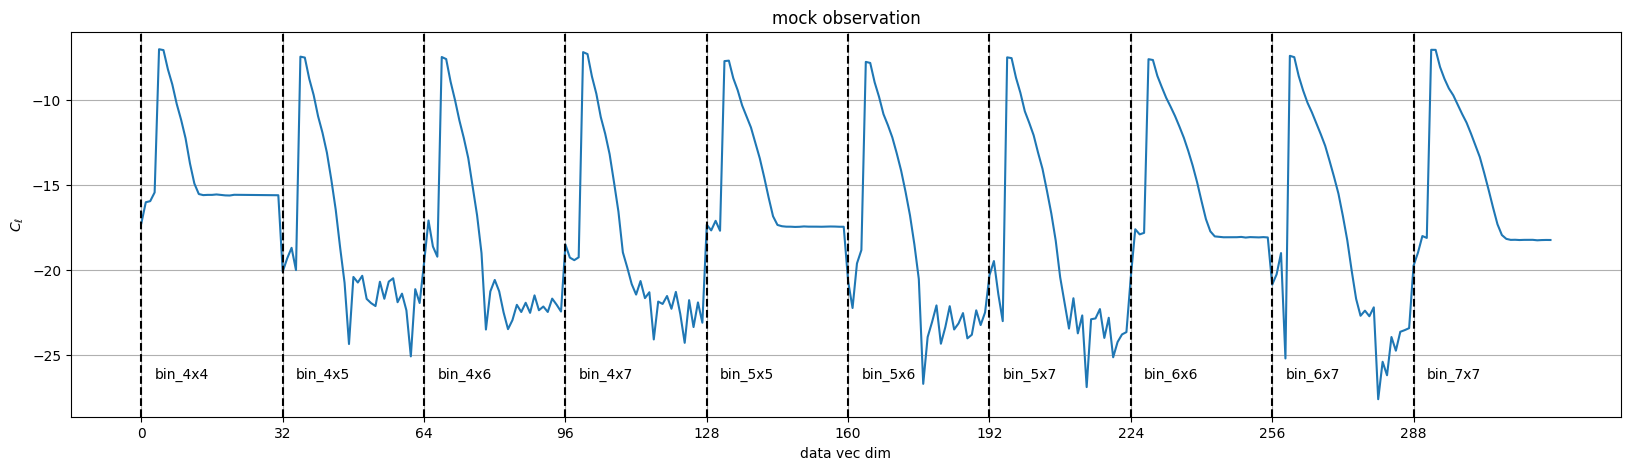

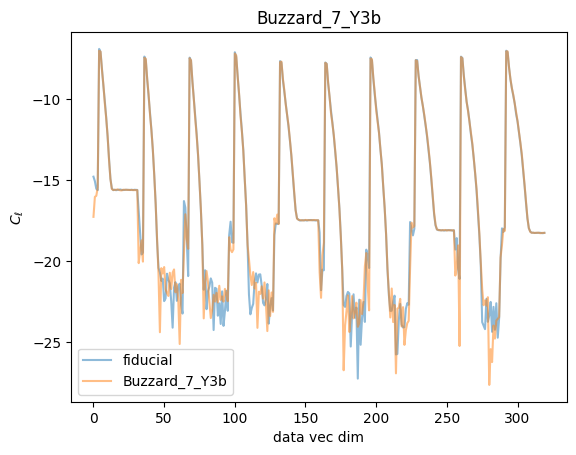

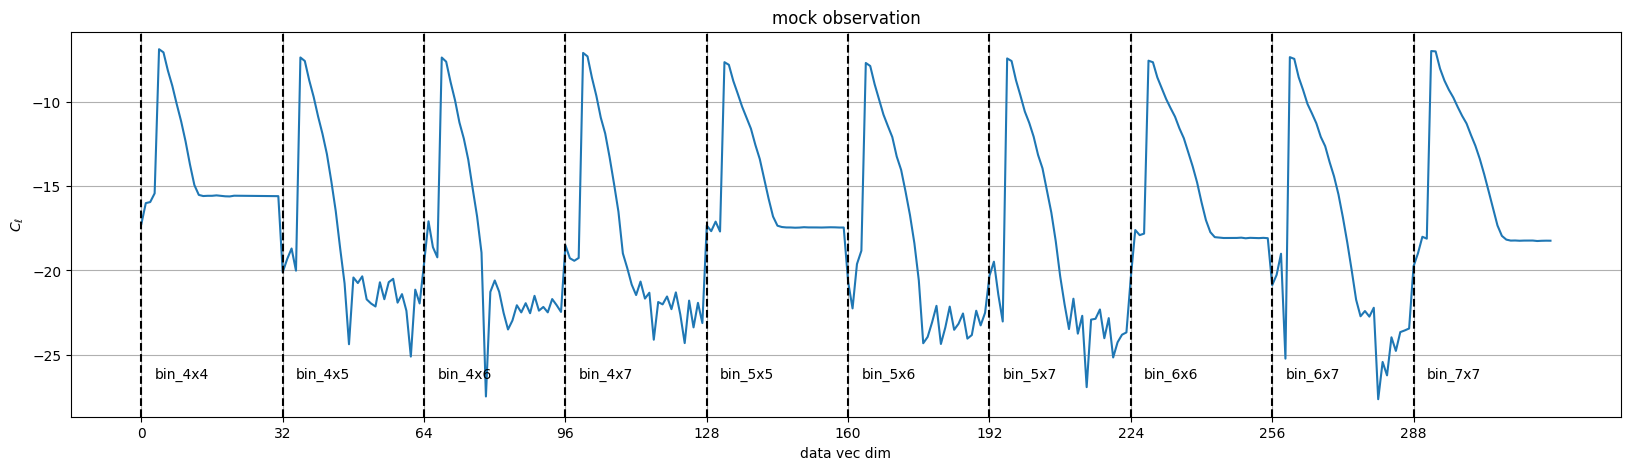

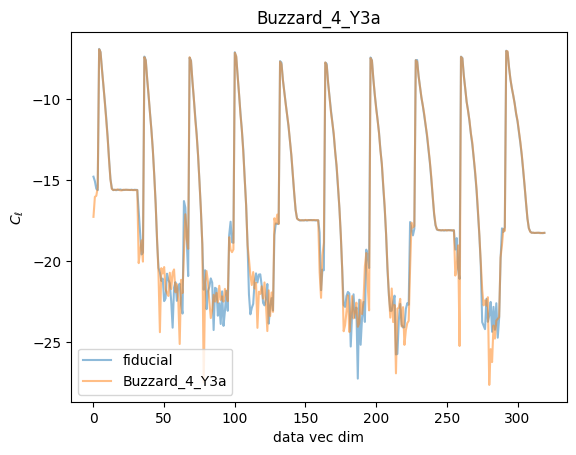

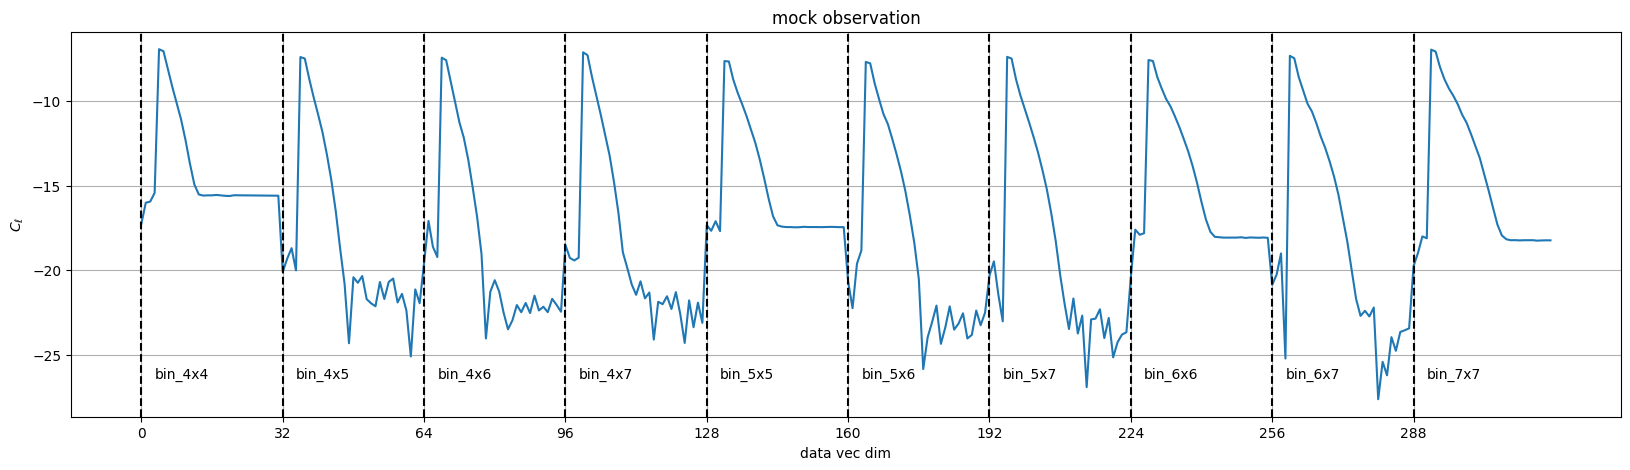

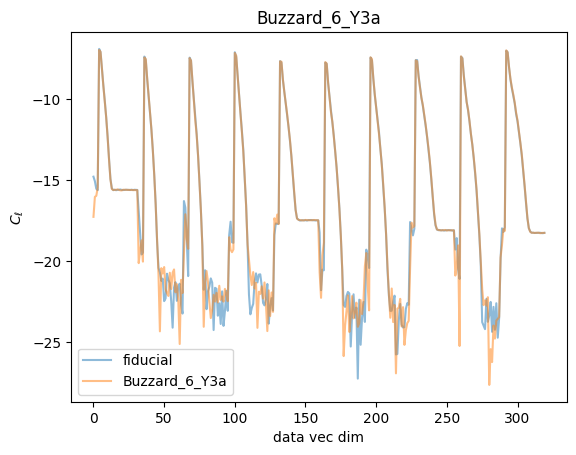

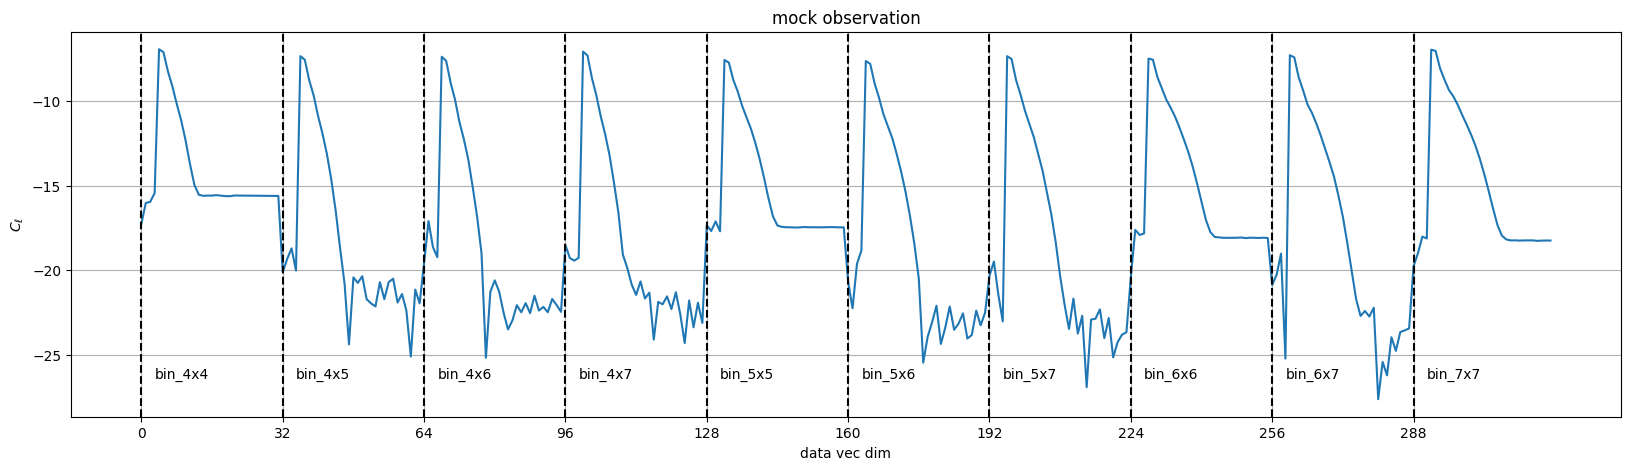

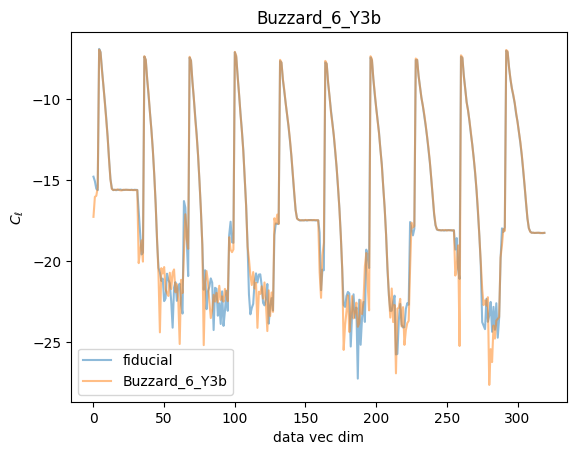

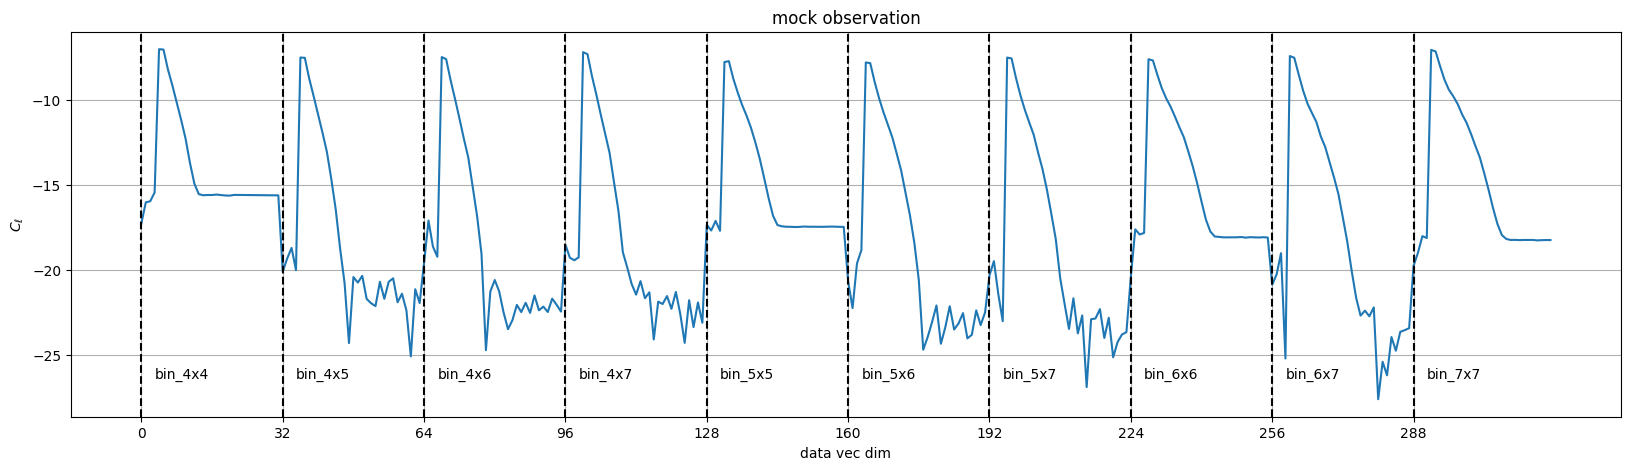

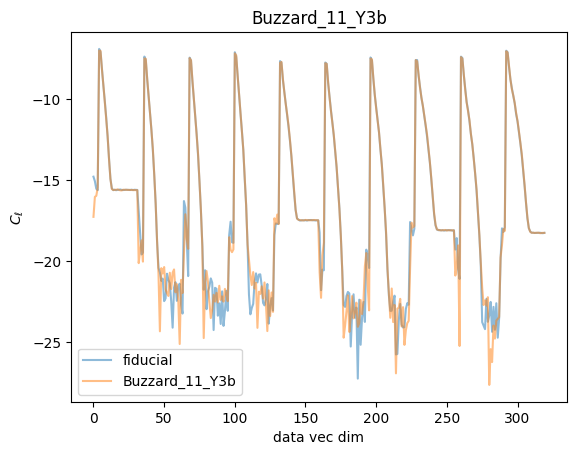

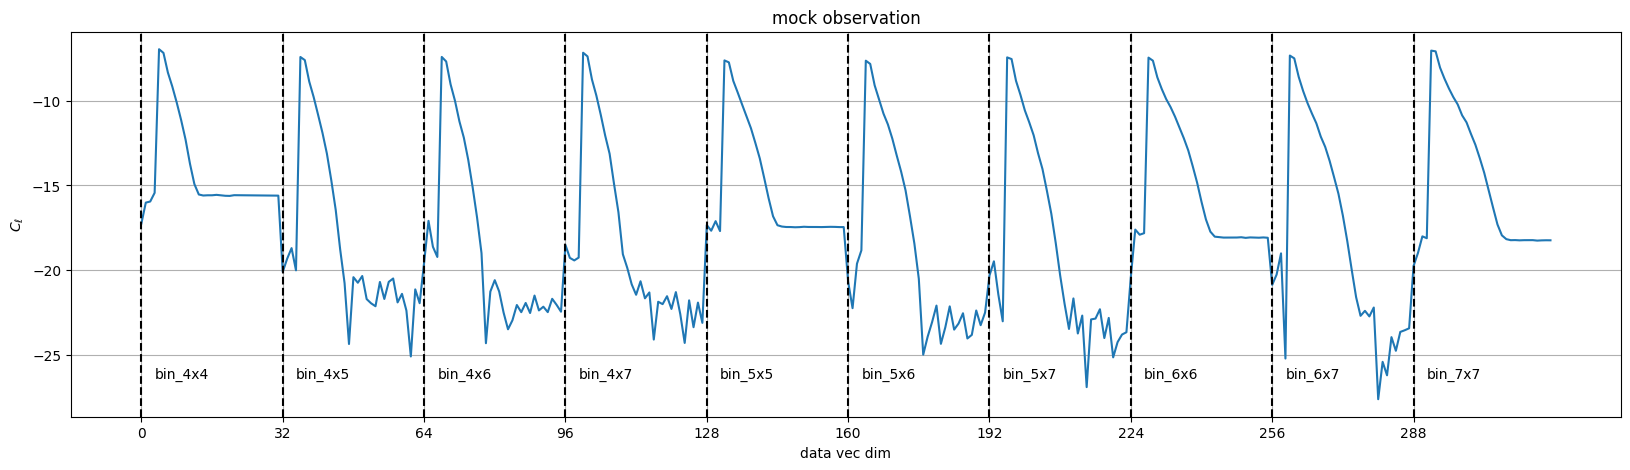

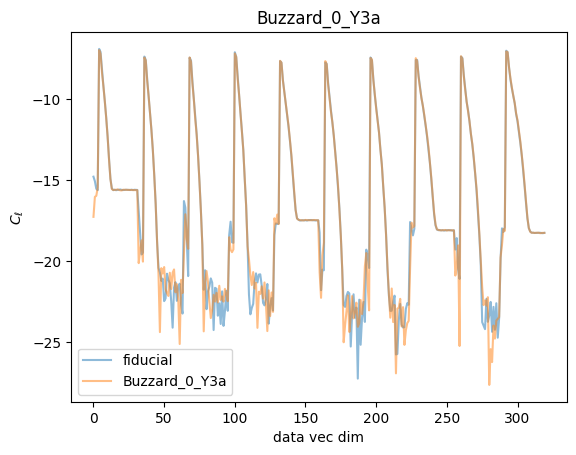

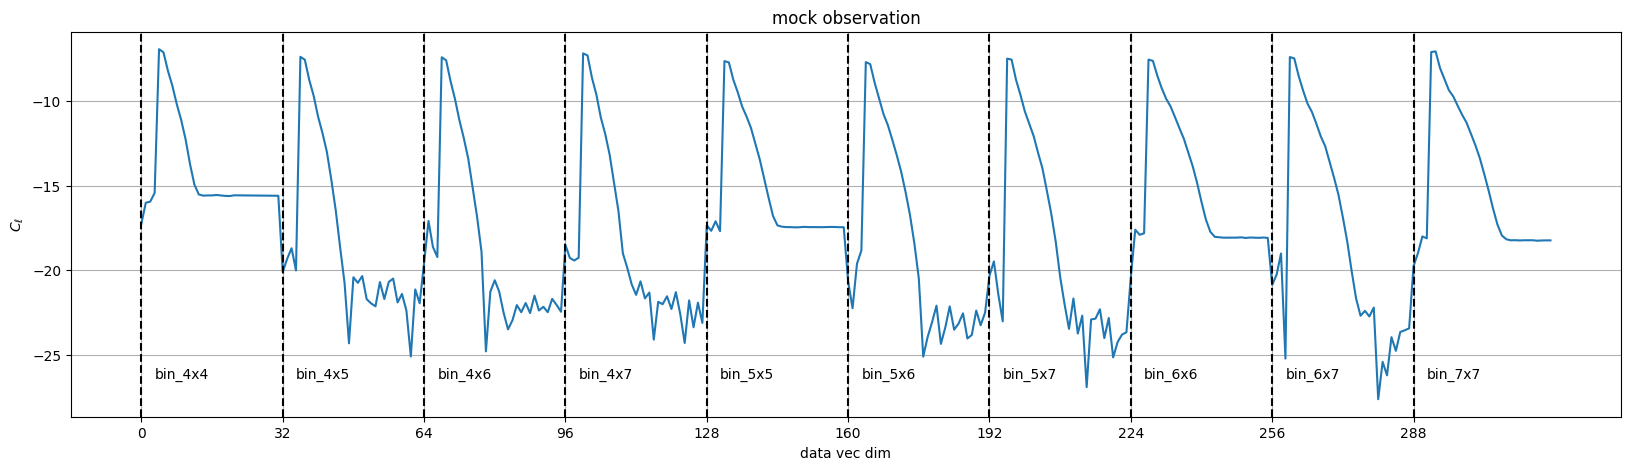

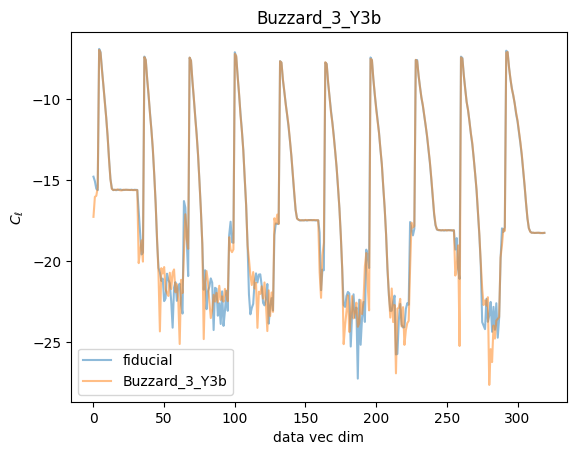

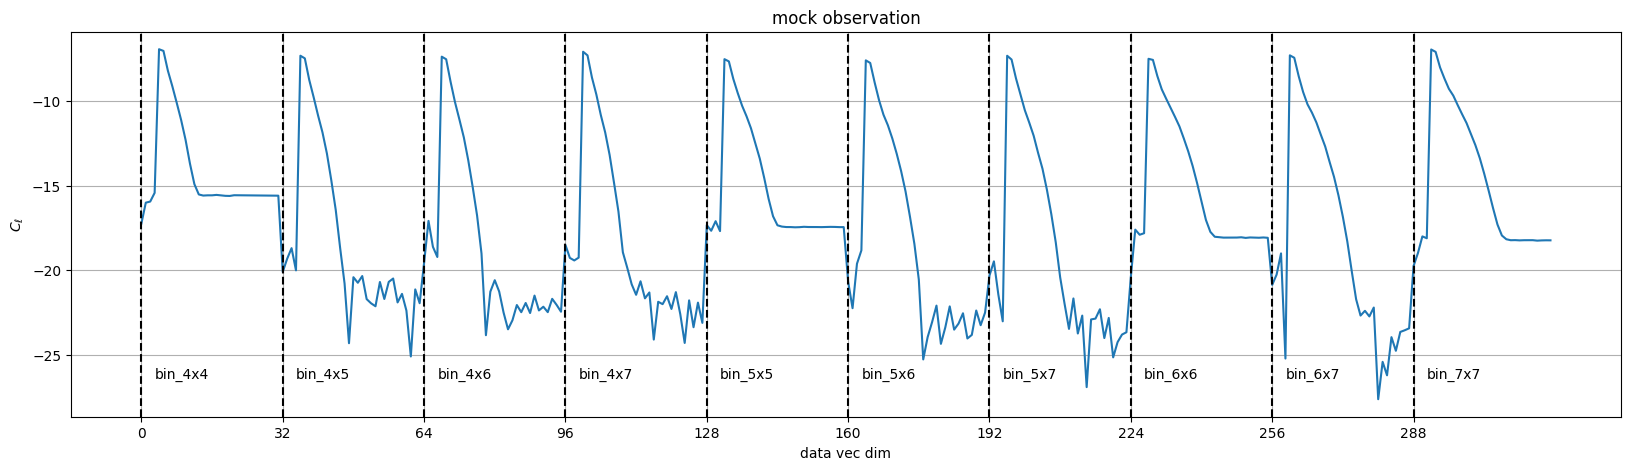

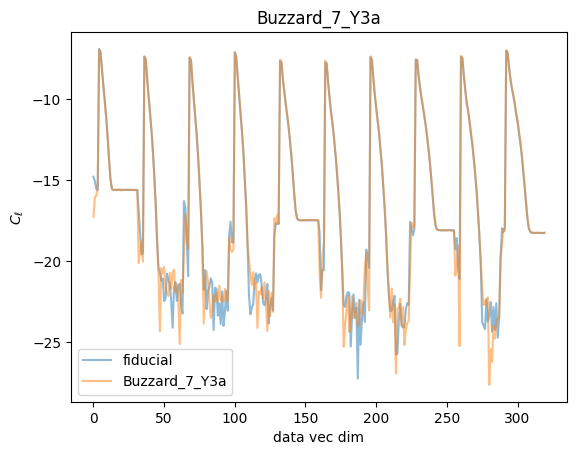

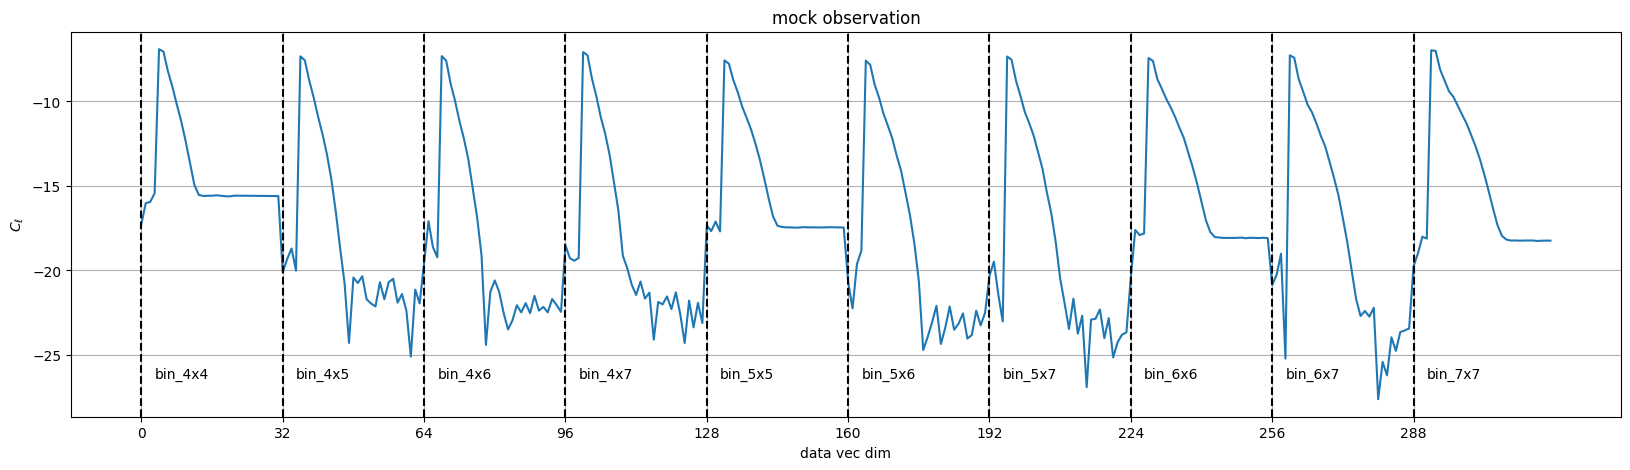

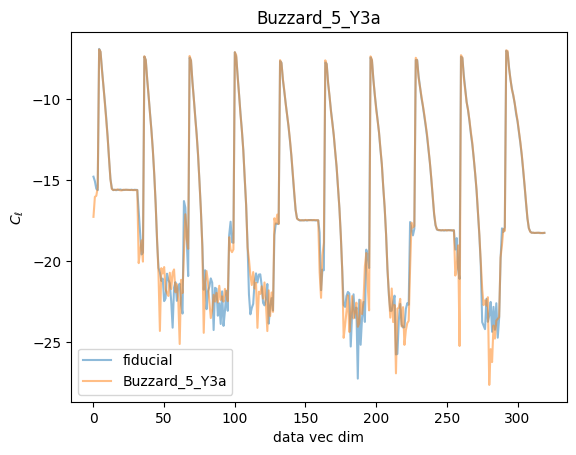

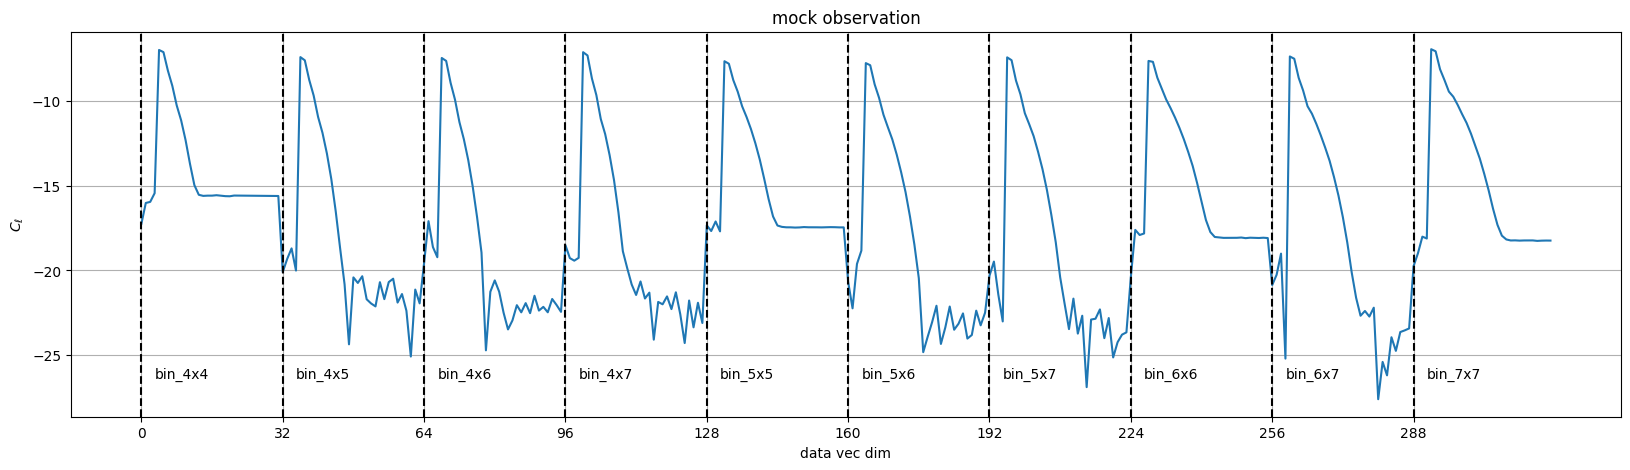

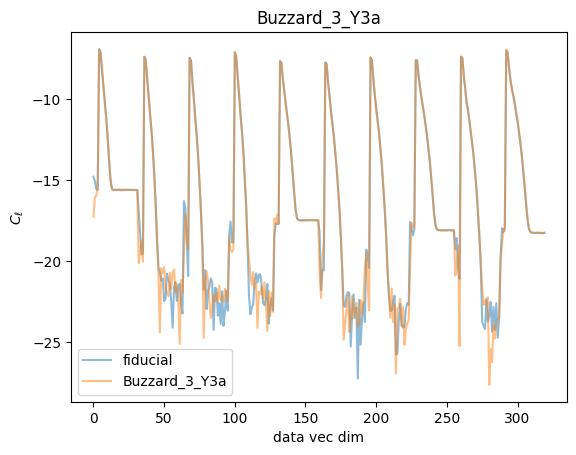

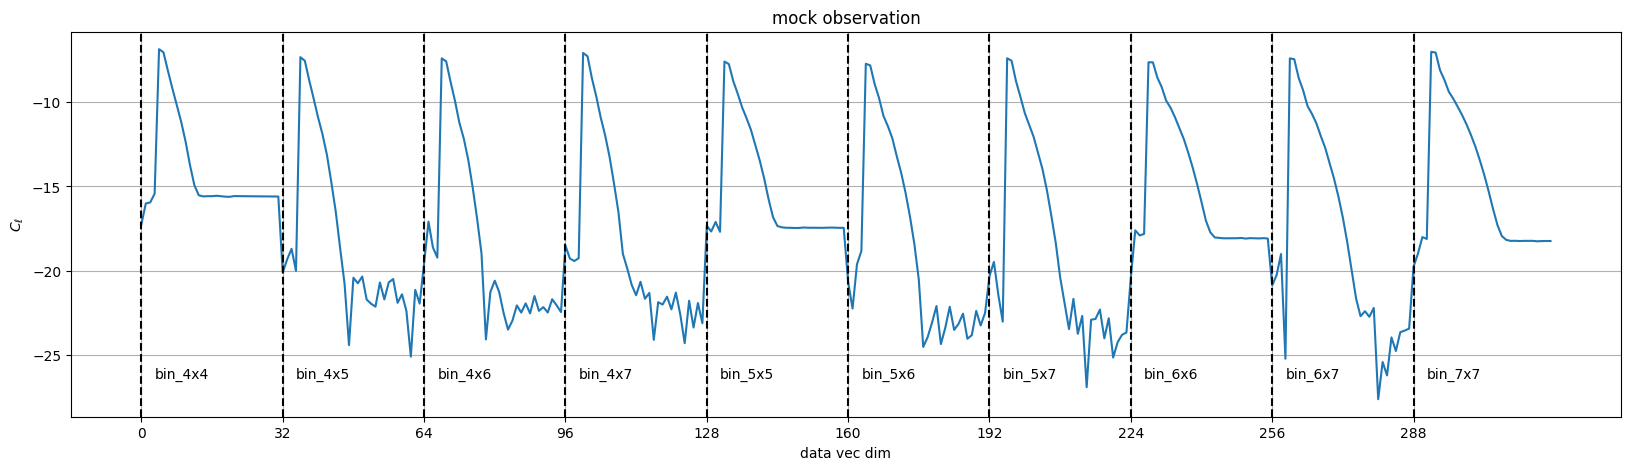

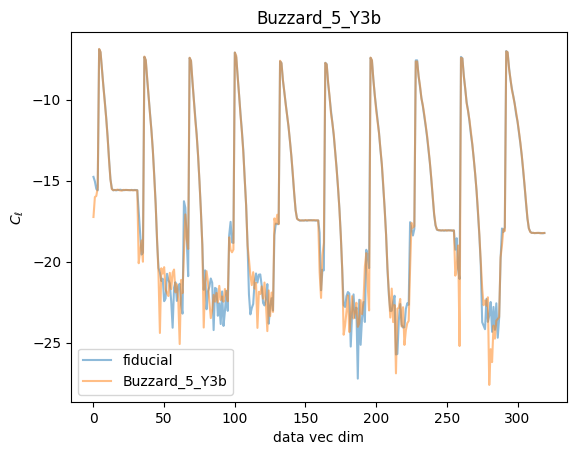

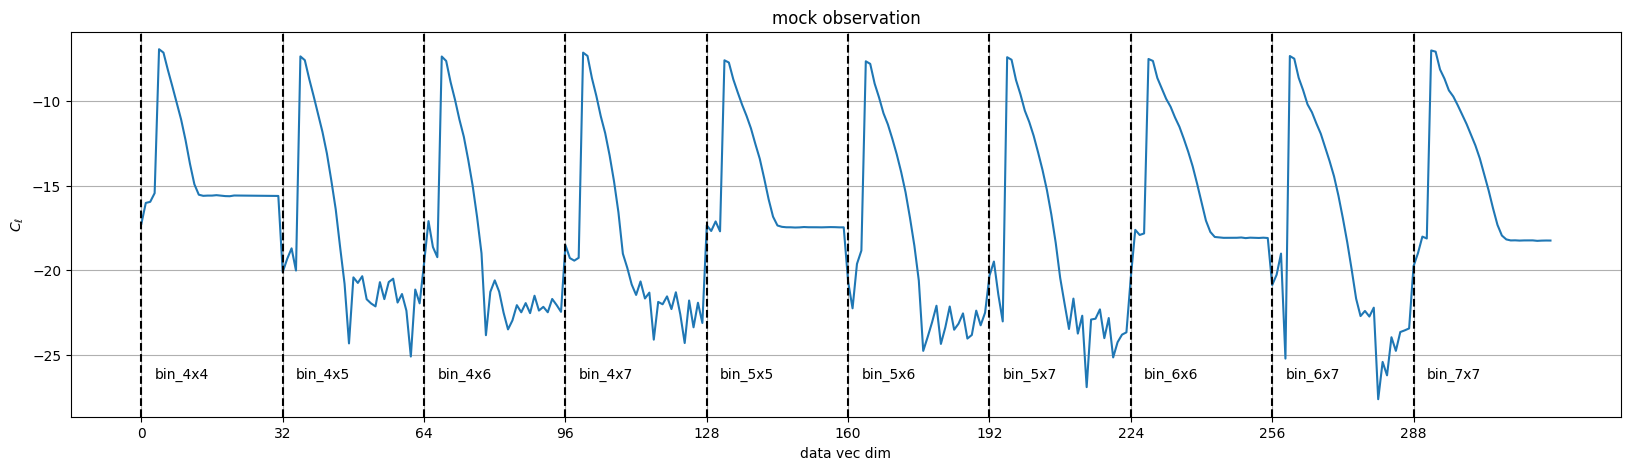

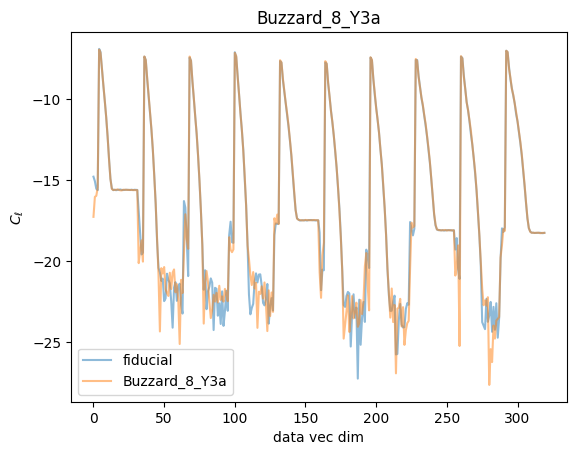

In [25]:
n_side = msfm_conf["analysis"]["n_side"]
n_pix = msfm_conf["analysis"]["n_pix"]
data_vec_pix = files.load_pixel_file(msfm_conf)[0]
hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
buzzard_flock_files = os.listdir(buzzard_flock_dir)

with h5py.File(pred_file, "a") as f_out:
    for buzzard_flock_file in buzzard_flock_files:
        obs_file = os.path.join(buzzard_flock_dir, buzzard_flock_file)
        obs_label = buzzard_flock_file[23:-3]
    
        with h5py.File(obs_file, "r") as f_in:
            gc_map = []
            for i in range(1,5):
                gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
            gc_map = np.stack(gc_map, axis=-1)

        obs_cl = preprocessing.get_preprocessed_cl_observation(
            wl_gamma_map=np.zeros((n_pix,4,2)),
            gc_count_map=gc_map,
            # configuration
            msfm_conf=msfm_conf,
            dlss_conf=dlss_conf,
            base_dir=base_dir,
            from_raw_cls=False,
            # selection
            with_lensing=with_lensing,
            with_clustering=with_clustering,
            with_cross_z=with_cross_z,
            with_cross_probe=(with_lensing and with_clustering),
            # bin_indices=[bin_index],
            # additional preprocessing
            apply_log=apply_log,
            # standardize=standardize,
            # scaler=scaler,
            # pca_components=None,
            # pca=pca,
        )
        
        fig, ax = plt.subplots()
        ax.plot(out_dict["fidu/cls"][0,:], label="fiducial", alpha=0.5)
        ax.plot(np.squeeze(obs_cl), label=obs_label, alpha=0.5)
        ax.legend(loc="best")
        ax.set(xlabel="data vec dim", ylabel=r"$C_\ell$", title=obs_label)

        obs_pred = model(obs_cl)
        print("\n", obs_label, obs_pred, "\n")
            
        f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)


# old

In [26]:
# file_dict = input_output.load_human_summaries(
#     "/pscratch/sd/a/athomsen/v11desy3/v12/nonlinear",
#     "cls",
#     file_label=None,
#     return_raw_cls=False,
#     return_fiducial=False,
#     return_grid=True,
#     cls_from_maps=False,
# )

# cosmo = file_dict["grid/cosmo"]
# print(cosmo.shape)

In [27]:
# pca_components = 32

# grid_pca, scaler, pca = preprocessing.preprocess_human_summaries(
#     out_dict["grid/cls/test"], apply_log, standardize=False, pca_components=pca_components
# )
# # fidu_summs, _, _ = preprocess_human_summaries(
# #     fidu_summs, apply_log, standardize=standardize, pca_components=pca_components, scaler=scaler, pca=pca
# # )


In [28]:
# fidu_ex = out_dict["fidu/cls"][0,:]
# mock_ex = np.squeeze(obs_cl)

# fig, ax = plt.subplots()

# ax.plot(fidu_ex, label="fiducial", alpha=0.5)
# ax.plot(mock_ex, label="mock", alpha=0.5)

# ax.legend(loc="best")
# # ax.set(yscale="log")

### constant learning rate, gradient clipping

In [29]:
# summary_net = get_cl_summary_network()
# optimizer = tf.keras.optimizers.Adam(1e-3)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": False}
# )

# train_model(model, do_validation=True)

In [30]:
# summary_net = get_cl_summary_network()
# optimizer = tf.keras.optimizers.Adam(1e-4)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": False}
# )

# train_model(model, do_validation=True)
# cosine_schedule = False

In [31]:
# summary_net = get_cl_summary_network()
# optimizer = tf.keras.optimizers.Adam(1e-3)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": True}
# )

# train_model(model, do_validation=True)
# cosine_schedule = False

### constant learning rate, no gradient clipping

In [32]:
# summary_net = get_cl_summary_network()
# optimizer = tf.keras.optimizers.Adam(1e-3)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=None,
#     mutual_info_kwargs={"full_covariance": True}
# )

# train_model(model, do_validation=True)
# cosine_schedule = False

### cosine decay

In [33]:
# summary_net = get_cl_summary_network()

# lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
#     initial_learning_rate=1e-3, decay_steps=n_steps, alpha=0.0
# )
# optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": False}
# )

# train_model(model, do_validation=True)
# cosine_schedule = True

In [34]:
# summary_net = get_cl_summary_network()

# lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
#     initial_learning_rate=1e-3, decay_steps=n_steps, alpha=0.0
# )
# optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=1.0,
#     mutual_info_kwargs={"full_covariance": True}
# )

# train_model(model, do_validation=True)
# cosine_schedule = True

# save results

In [35]:
# fidu_preds = model(out_dict["fidu/cls"])
# grid_preds = model(out_dict["grid/cls/test"])

# # pred_file = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},steps={n_steps}/preds.h5")
# pred_file = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_schedule},steps={n_steps}/preds.h5")
# # pred_file = os.path.join(out_dir, "cls/mutual_info", f"lensing={with_lensing},clustering={with_clustering},steps={n_steps}/preds.h5")
# os.makedirs(os.path.dirname(pred_file), exist_ok=True)

# with h5py.File(pred_file, "w") as f:
#     f.create_dataset(name="grid/preds/test", data=grid_preds)
#     f.create_dataset(name="grid/cosmos/test", data=out_dict["grid/cosmos/test"])
#     f.create_dataset(name="fidu/preds", data=fidu_preds)
    
# print(f"Wrote to {pred_file}")

In [36]:
# n_side = msfm_conf["analysis"]["n_side"]
# n_pix = msfm_conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(msfm_conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# with h5py.File(pred_file, "a") as f_out:
#     for obs_label in mocks:
#         obs_file = f"/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_mock_observation_{obs_label}.h5"

#         with h5py.File(obs_file, "r") as f_in:
#             gc_map = []
#             for i in range(1,5):
#                 gc_map.append(f_in[f"maglim/galaxy_counts_bin{i}"][:])
#             gc_map = np.stack(gc_map, axis=-1)

#         obs_cl = preprocessing.get_preprocessed_cl_observation(
#             wl_gamma_map=np.zeros((n_pix,4,2)),
#             gc_count_map=gc_map,
#             # configuration
#             conf=msfm_conf,
#             from_raw_cls=True,
#             # selection
#             with_lensing=with_lensing,
#             with_clustering=with_clustering,
#             with_cross_z=True,
#             with_cross_probe=(with_lensing and with_clustering),
#             # CLs scale cuts
#             l_mins=l_mins,
#             l_maxs=l_maxs,
#             n_bins=n_bins,
#             # additional preprocessing
#             apply_log=apply_log,
#             standardize=standardize,
#             scaler=scaler,
#             pca_components=None,
#             pca=pca,
#         )
        
#         obs_pred = model(obs_cl)
#         print("\n", obs_label, obs_pred, "\n")
            
#         f_out.create_dataset(name=f"mocks/{obs_label}", data=obs_pred)
